In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve

from copy import deepcopy
from jax.lax import slice as jax_slice
from jax.scipy.signal import convolve2d

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)

        self.space = space
        self.factor = factor
        self.center = center
        self.shape = tuple(d*self.factor for d in self.space)

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor})'

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()

    @property
    def llp(self):
        return (self.cen - 0.5 * (self.dom - 1)) * self.factor

    @property
    def urp(self):
        return (self.cen + 0.5 * (self.dom - 1)) * self.factor

    def update(self, space=None, center=None, factor=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        return SignalGrid(space, center, factor)



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_grid = in_grid.update(factor=out_grid.factor)
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center:
        out_array = np.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif, 0)
        in_max = np.minimum(urp_dif + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif, 0)
        out_max = np.minimum(out_grid.shp - urp_dif, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array[out_slc] = in_array[in_slc]
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

In [3]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val

In [4]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


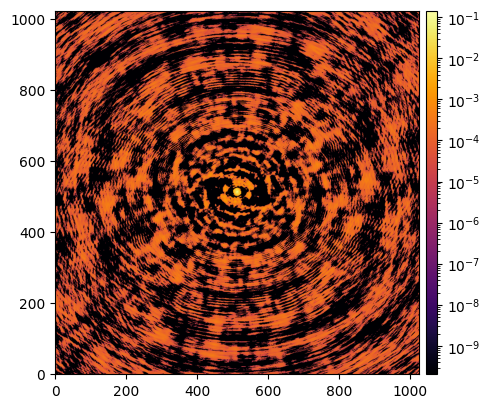

In [5]:
space_512 = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space_512)

kernel_512 = compute_psf_kernel(RNR_l)

plot_arrays(kernel_512, norm='log', dpi=100)

In [6]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')



exp_it = 3
sky_it = optim_cfg.instantiate_sec(f'sky.{exp_it}')

skies_c, means_c = [], []
with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    smp_c, *_ = pickle.load(f)
for sky_c in sky_it.signals + sky_it.points:
    print(sky_c.prefix)
    mean = smp_c.mean(sky_c)
    skies_c += [sky_c, ]
    means_c += [map_signal(mean, sky_c.space, skies_c[0].space), ]

signal_bg, space_bg = downsample(means_c[0], 2), skies_c[0].space * 0.5
signal_t0, space_t0 = downsample(means_c[1], 2), skies_c[1].space * 0.5
signal_t1, space_t1 = downsample(means_c[2], 2), skies_c[2].space * 0.5
signal_t2, space_t2 = downsample(means_c[3], 2), skies_c[3].space * 0.5
# signal_ps, space_ps = smp_c.mean(sky_it.points[0].points), skies_c[4].space
signal_sum = signal_bg + signal_t0 + signal_t1 + signal_t2

bg.3
o0.3
o1.3
o2.3
p0.3


In [7]:
grid_sum = SignalGrid(space=(128, 128), center=(0, 0), factor=2)
grid_bg = SignalGrid(space=(128, 128), center=(0, 0), factor=1)
grid_t0 = SignalGrid(space=(20, 28), center=(-2, -4), factor=2)
grid_t1 = SignalGrid(space=(10, 10), center=(-12, 16), factor=2)
grid_t2 = SignalGrid(space=(10, 10), center=(-12, 24), factor=2)

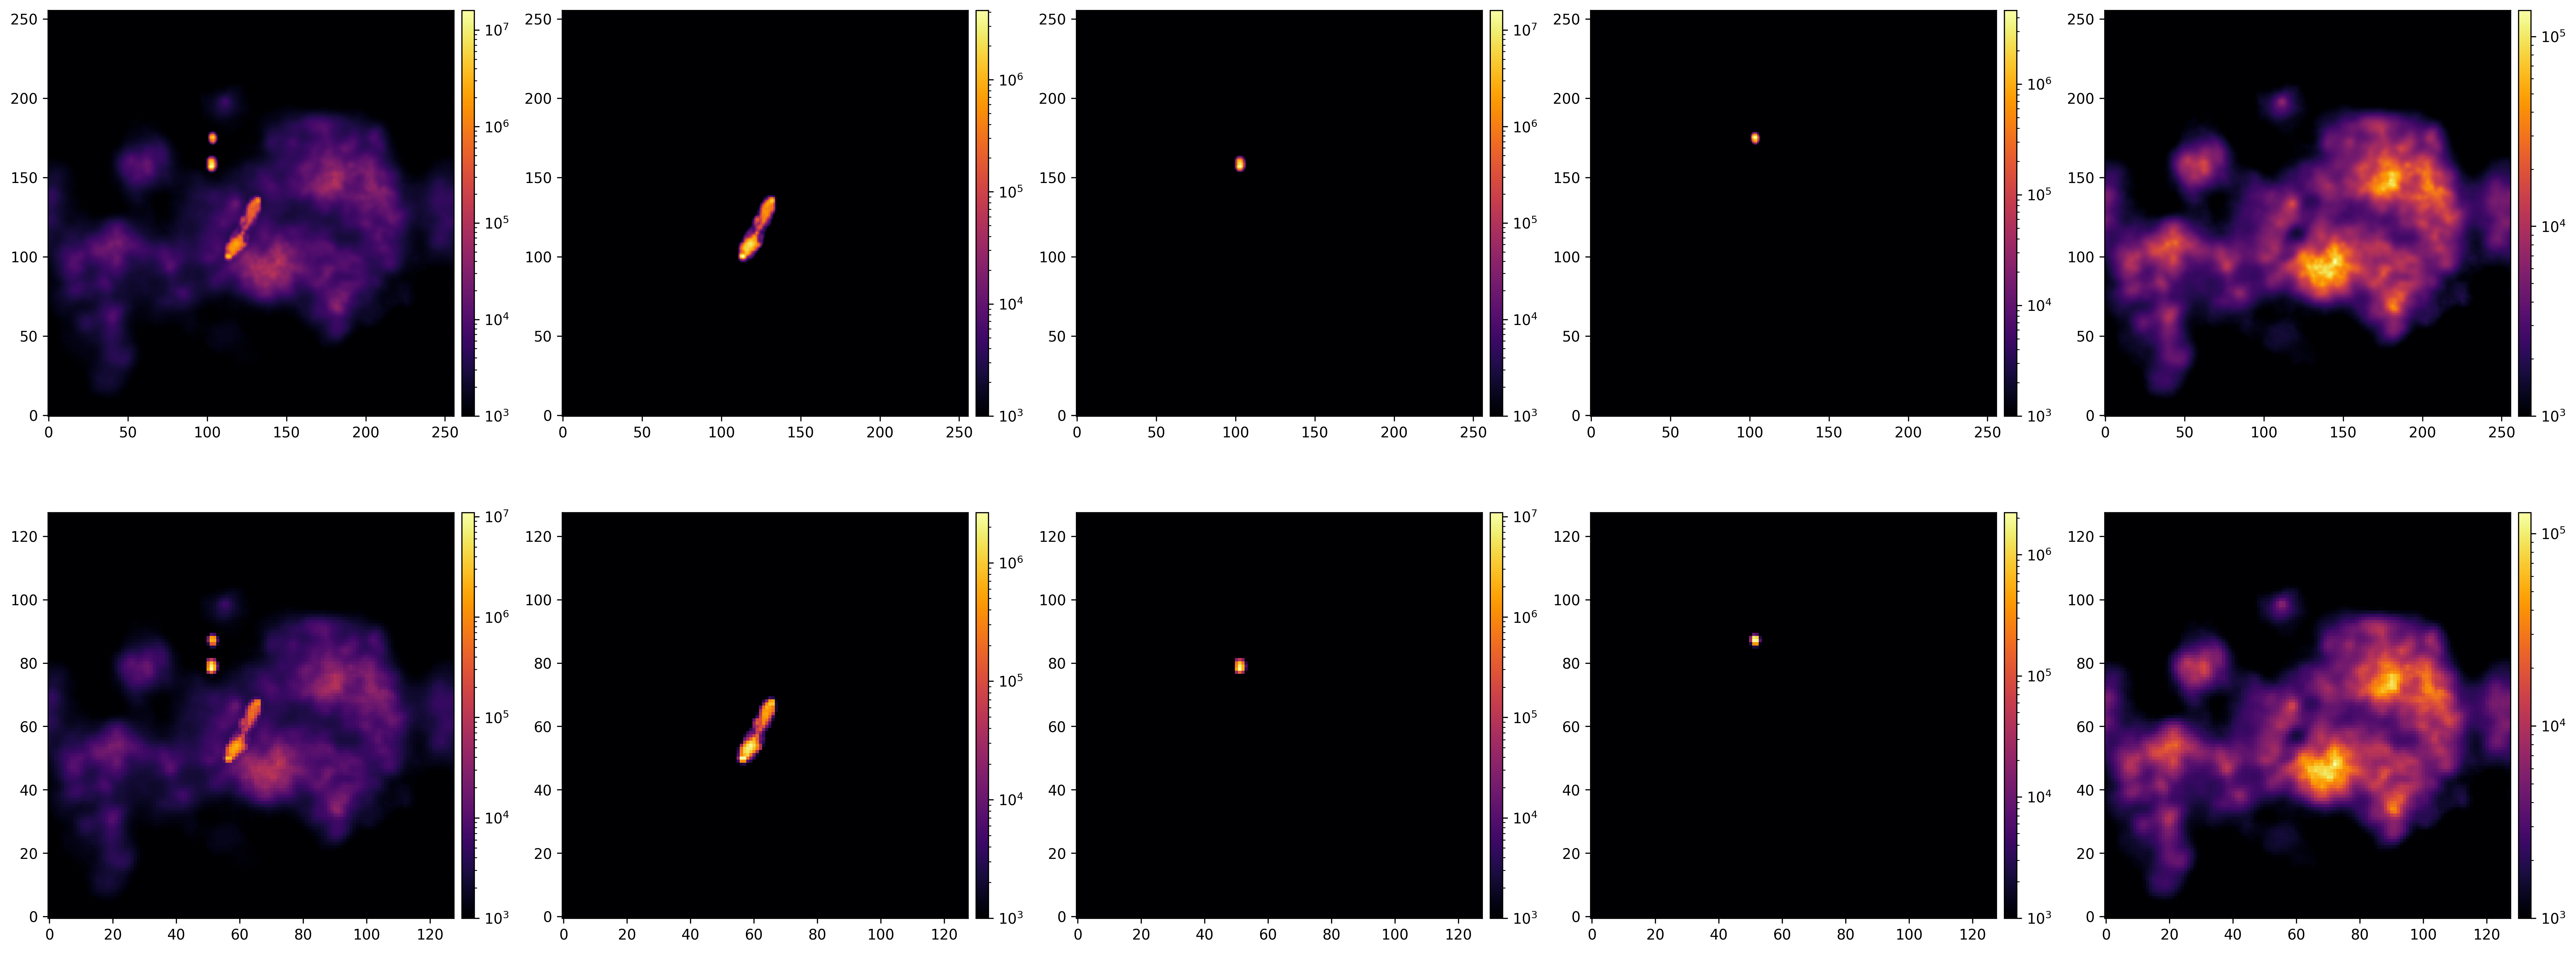

In [8]:
zoom = 2

signal_dict = {
    'sum': {'val': signal_sum, 'low': downsample(signal_sum, zoom), 'spc': grid_sum},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'spc': grid_t0},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'spc': grid_t1},
    't2': {'val': signal_t2, 'low': downsample(signal_t2, zoom), 'spc': grid_t2},
    # 'ps': {'val': means_c[3], 'low': downsample(means_c[3], zoom), 'spc': skies_c[3].points.space},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom), 'spc': grid_bg},
    'fac': zoom,
}

kernel = downsample(kernel_512, zoom)

plot_arrays([sig['val'] for sig in signal_dict.values() if isinstance(sig, dict)] + [sig['low'] for sig in signal_dict.values() if isinstance(sig, dict)], norm='log', dpi=300, rows=2, vmin=1e3)

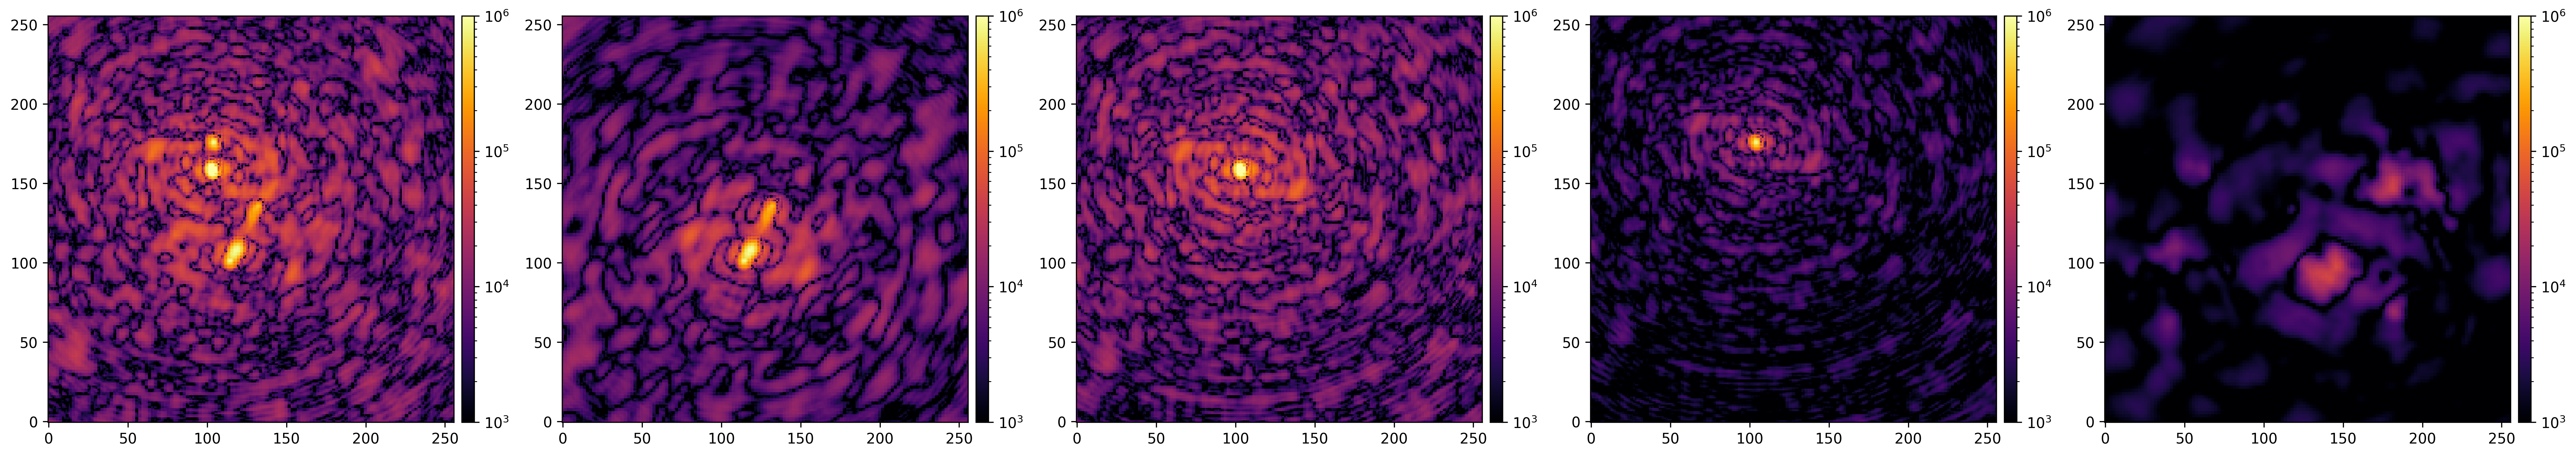

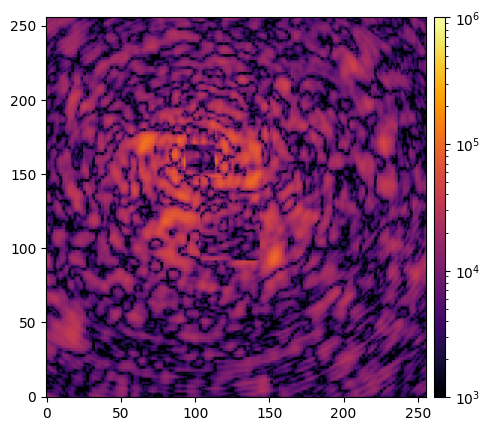

In [9]:
rsp_err = []
low_res_err = np.zeros_like(signal_dict['sum']['val'])
ker_low = downsample(kernel, zoom)
for k,sig in signal_dict.items():
    if isinstance(sig, dict):
        rsp_low = convolve2d(sig['low'], ker_low, mode='same') * zoom
        rsp_low = upsample(rsp_low, zoom)
        rsp_val = convolve2d(sig['val'], kernel, mode='same')
        rsp_err += [rsp_val - rsp_low, ]
        if k != 'sum':
            low_res_err += (rsp_val - rsp_low) * (1 - map_array(np.ones(sig['spc'].shape), sig['spc'], signal_dict['sum']['spc']))

plot_arrays([np.abs(err) for err in rsp_err], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)
plot_arrays([np.abs(low_res_err)], dpi=100, rows=1, norm='log', vmin=1e3, vmax=1e6)

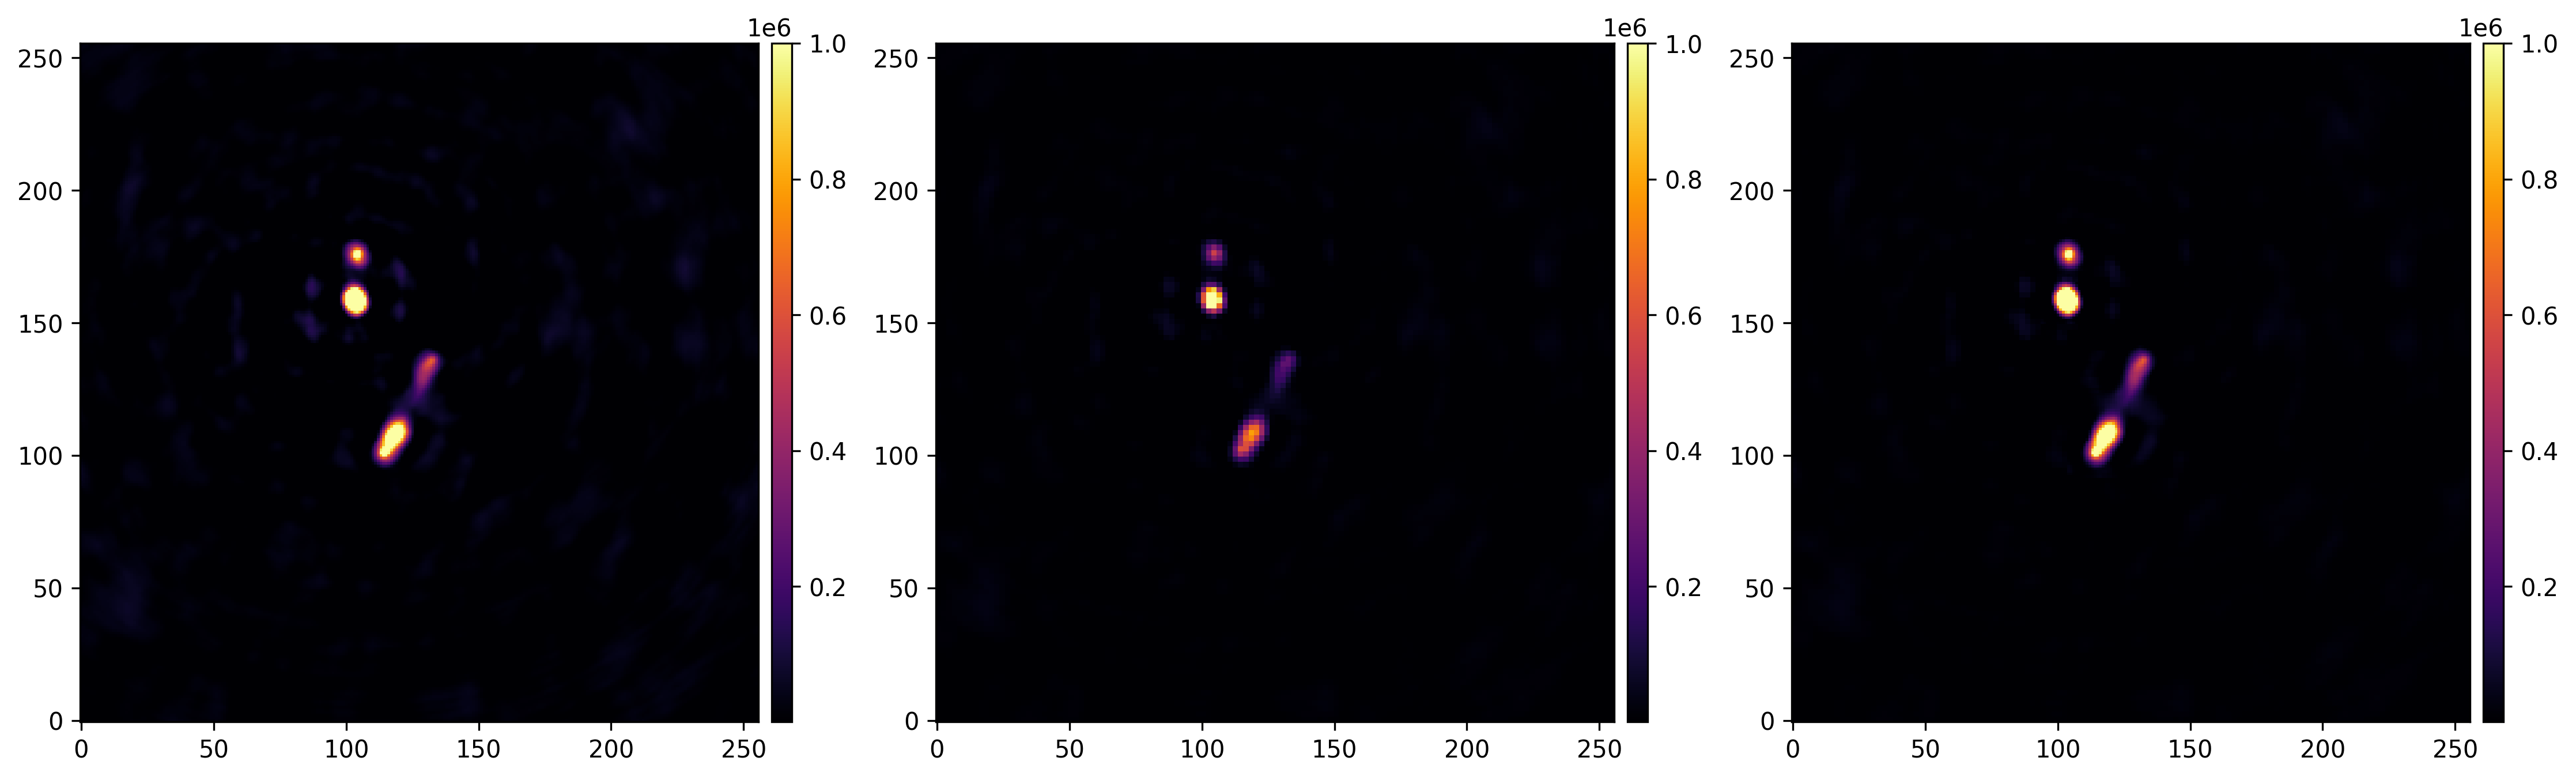

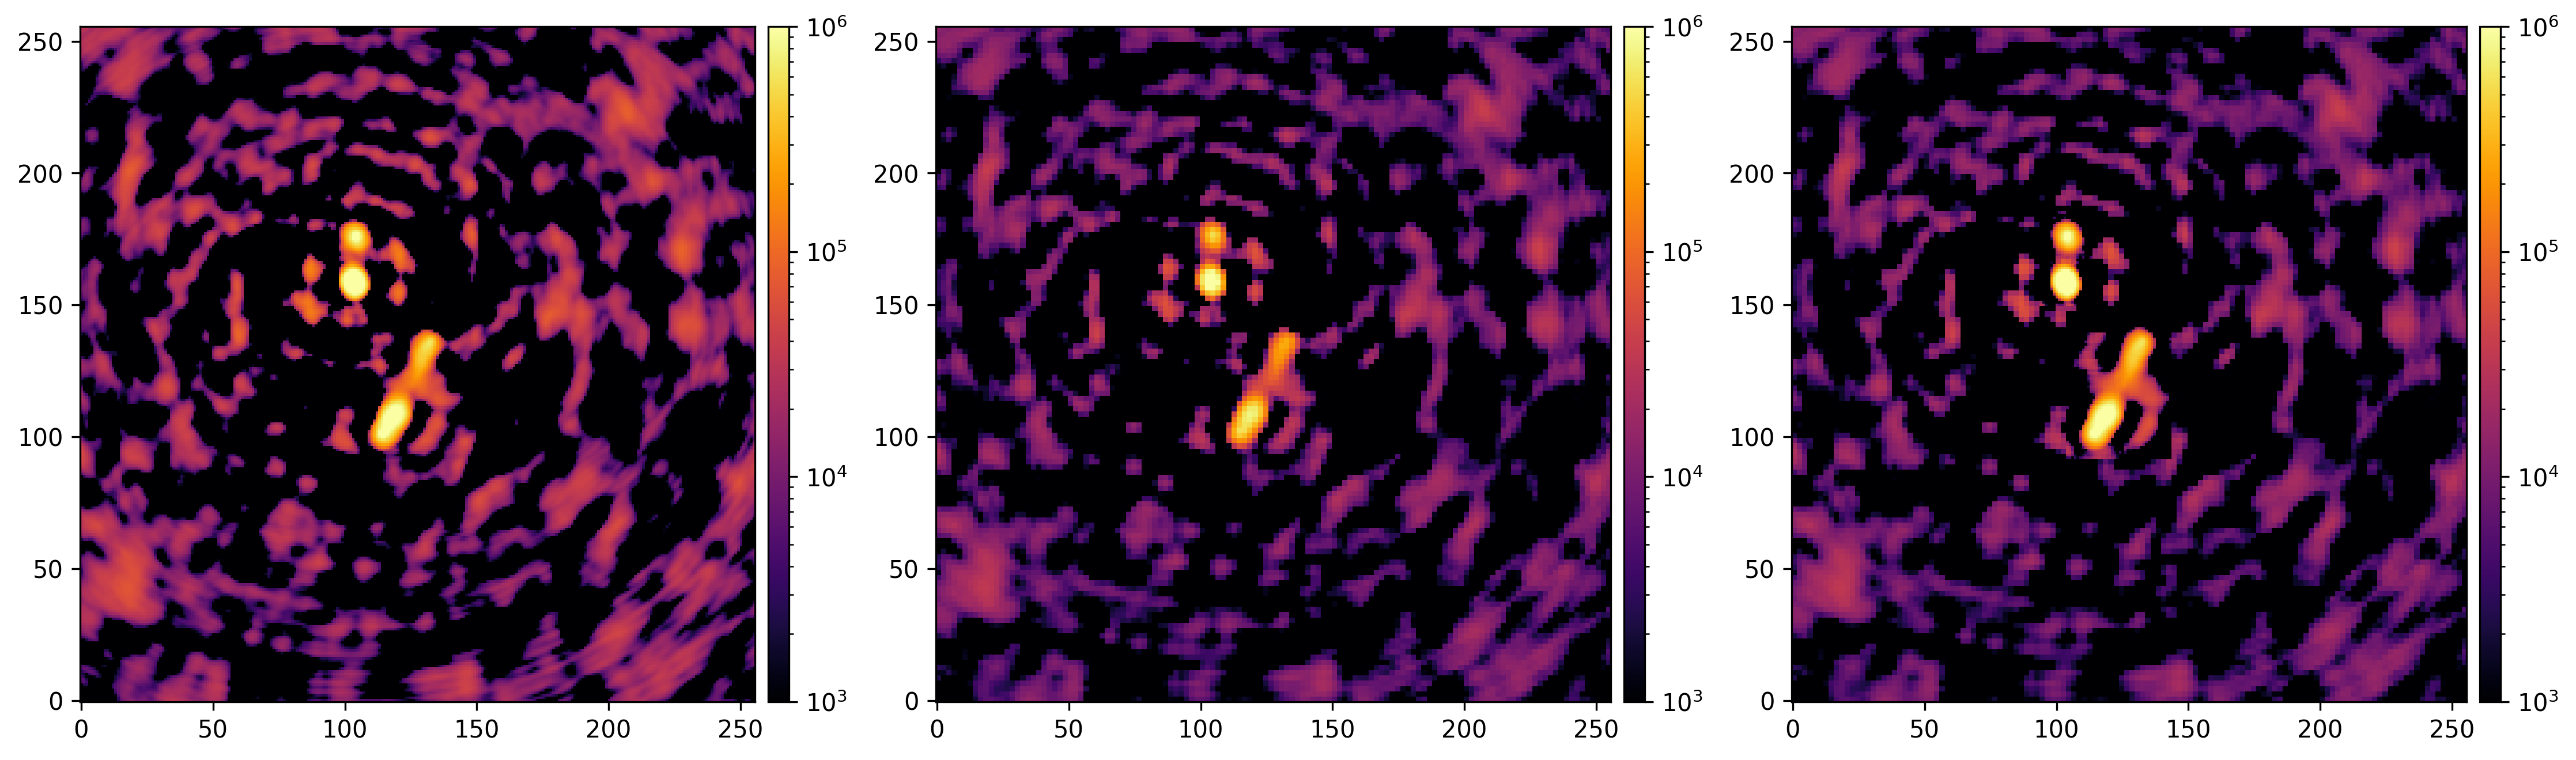

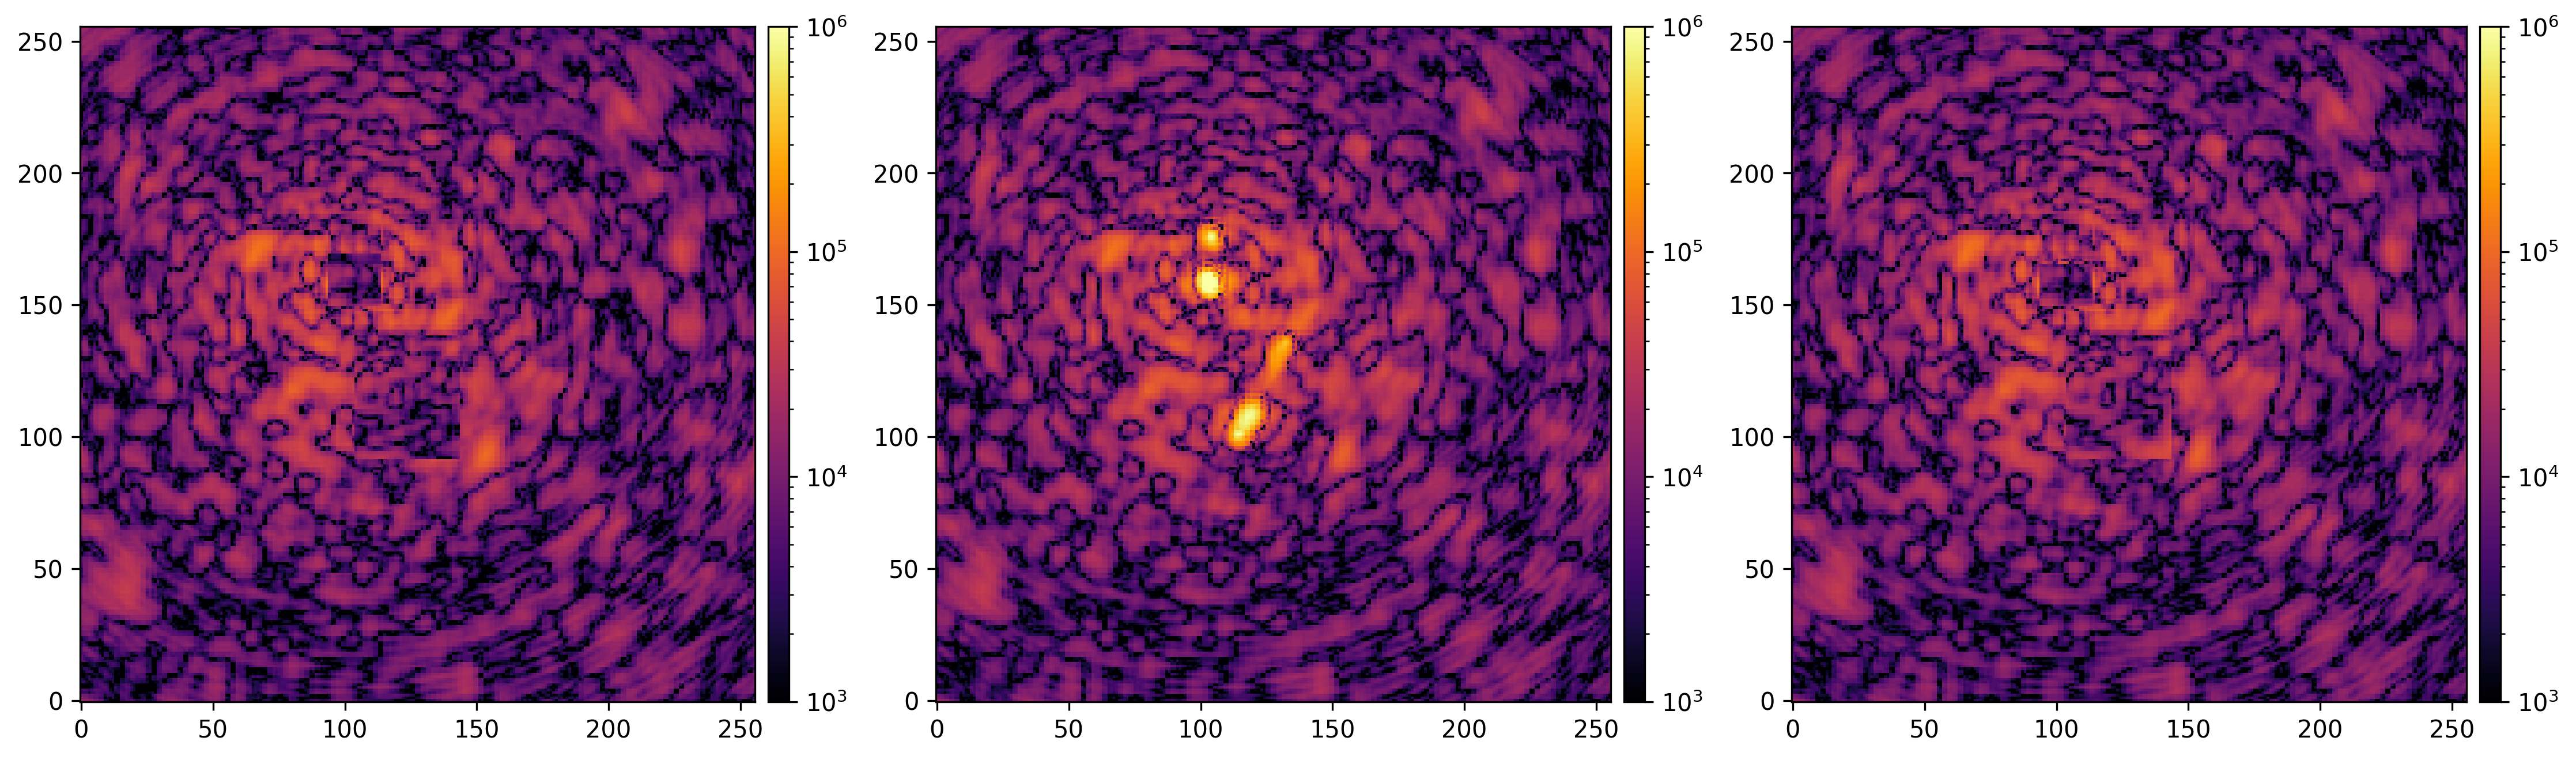

In [10]:
def multi_scale_kernel(signal_dict, kernel):
    signal_dict = deepcopy(signal_dict)
    fac = signal_dict['fac']
    grid = signal_dict['sum']['spc']
    grid_low = signal_dict['bg']['spc']

    kernel_low = downsample(kernel, fac)
    response_low = convolve2d(signal_dict['sum']['low'], kernel_low, mode='same') * fac
    response_val = upsample(response_low, fac)

    for key, sig in filter(lambda x: 't' in x[0], signal_dict.items()):
        sig_high = map_array(sig['val'], grid, sig['spc'])
        ker_high = map_array(kernel, grid.update(factor=4), sig['spc'].update(center=(0,0), factor=4))
        rsp_high = convolve2d(sig_high, ker_high, mode='same')

        sig_low = map_array(sig['low'], grid_low, sig['spc'].update(factor=1))
        ker_low = downsample(ker_high, fac)
        rsp_low = convolve2d(sig_low, ker_low, mode='same') * fac

        rsp_slc = map_array(response_low, grid_low, sig['spc'].update(factor=1))
        rsp_sub = rsp_slc - rsp_low
        rsp_add = upsample(rsp_sub, fac) + rsp_high
        rsp_val = map_array(rsp_add, sig['spc'], grid)

        msk_val = map_array(np.ones(sig_high.shape), sig['spc'], grid)
        response_val = response_val * (1 - msk_val).clip(0, 1) + rsp_val

    # for key, sig in filter(lambda x: 'ps' in x[0], signal_dict.items()):
    #     slc = slice(sig['idx'] - sig['ker_pix']//2, sig['idx'] + sig['ker_pix']//2)
    #     slc_low = slice(slc.start//fac, slc.stop//fac)

    #     ker_high = kernel[kernel.size//2 - sig['ker_pix']//2 : kernel.size//2 + sig['ker_pix']//2]
    #     rsp_val = ker_high * sig['val'][sig['idx']]

    #     ker_low = downsample(ker_high, fac)
    #     rsp_low = ker_low * sig['low'][sig['idx']//fac] * fac

    #     rsp_slc = response_low[slc_low]
    #     rsp_sub = rsp_slc - rsp_low
    #     rsp_add = upsample(rsp_sub, fac) + rsp_val
    #     response_val[slc] = rsp_add

    return response_val


response_high = convolve2d(signal_dict['sum']['val'], kernel, mode='same')
response_low = convolve2d(signal_dict['sum']['low'], downsample(kernel, signal_dict['fac']), mode='same') * signal_dict['fac']
response_low = upsample(response_low, signal_dict['fac'])


response_ms = multi_scale_kernel(signal_dict, kernel)

plot_arrays([response_high, response_low, response_ms], dpi=300, rows=1, vmin=1e3, vmax=1e6)
plot_arrays([response_high, response_low, response_ms], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)

response_errors = [low_res_err, response_high - response_low, response_high - response_ms]

plot_arrays([np.abs(err) for err in response_errors], dpi=300, rows=1, norm='log', vmin=1e3, vmax=1e6)